In [1]:
from graphMatching import *
from networkx import read_edgelist
from scipy.io import loadmat
from model import *
from utils import *

In [2]:
# import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.cluster import HDBSCAN
from sklearn.manifold import TSNE
import matplotlib.colors as mcolors
import umap

In [3]:
data = "MS" # args.dataset

device = torch.device('cuda:1' if torch.cuda.is_available() else "cpu")
train_features = {}
if (data == "ACM_DBLP"):
	train_set = ["ACM", "DBLP"]
	input_dim = 17
	b = np.load('data/ACM-DBLP.npz')
	train_features["ACM"] = [torch.from_numpy(b["x1"]).float()]
	train_features["DBLP"] = [torch.from_numpy(b["x2"]).float()]
	test_pairs = b['test_pairs'].astype(np.int32)
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = 1024
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100
elif (data == "Douban Online_Offline"):
	a1, f1, a2, f2, test_pairs = load_douban()
	f1 = f1.A
	f2 = f2.A
	train_set = ["Online", "Offline"]
	input_dim = 538
	test_pairs = torch.tensor(np.array(test_pairs, dtype=int)) - 1
	test_pairs = test_pairs.numpy()
	train_features["Online"] = [torch.from_numpy(f1).float()]
	train_features["Offline"] = [torch.from_numpy(f2).float()]
	NUM_HIDDEN_LAYERS = 6
	HIDDEN_DIM = 512
	output_feature_size = 512
	lr = 0.0001
	epoch = 100
elif (data == "MS"):
	train_set = ["WT_3", "WT_5", "zwf1_1", "zwf1_3"] # change
	input_dim = 3 # features
		
	for dataset in train_set:
		df_nodes = pd.read_csv("graphs_data/nodes_{}.csv".format(dataset))
		train_features[dataset] = [torch.from_numpy(df_nodes.iloc[:, 2:].values).float()]
	
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = 1024
	output_feature_size = 128 # 
	lr = 0.0001
	epoch = 100

In [4]:
""" temp = torch.from_numpy(b["x1"]).float() # G1, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x1"]).float() # G1, features\nprint(temp.shape)\ntemp '

In [5]:
""" temp = torch.from_numpy(b["x2"]).float() # G2, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x2"]).float() # G2, features\nprint(temp.shape)\ntemp '

In [6]:
""" temp = b["test_pairs"]
print(temp.shape)
temp """

' temp = b["test_pairs"]\nprint(temp.shape)\ntemp '

In [7]:
# test_pairs

In [8]:
print(train_set)

['WT_3', 'WT_5', 'zwf1_1', 'zwf1_3']


In [9]:
encoder = "GIN"
use_input_augmentation = True
use_output_augmentation = False
print("Loading training datasets")
train_loader = {}
for dataset in train_set:
	df_edges_orange = pd.read_csv("graphs_data/edges_{}.csv".format(dataset))
	edges = df_edges_orange.iloc[:, [0, 1]].values
	
	n = train_features[dataset][0].shape[0]
	matrix = torch.zeros(n, n)

	for item in edges:
		matrix[item[0]][item[1]] = 1
		matrix[item[1]][item[0]] = 1
	train_loader[dataset] = [matrix]
train_loader

Loading training datasets


{'WT_3': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'WT_5': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'zwf1_1': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 1., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 1., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'zwf1_3': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0.

In [10]:
train_loader.keys()

dict_keys(['WT_3', 'WT_5', 'zwf1_1', 'zwf1_3'])

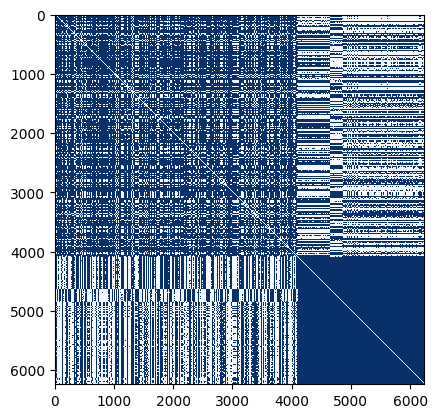

In [11]:
plt.imshow(train_loader[train_set[0]][0].cpu().numpy(), cmap="Blues", interpolation="none")
plt.show()

In [12]:
""" temp = train_loader["ACM"][0]
print(temp.shape)
temp """

' temp = train_loader["ACM"][0]\nprint(temp.shape)\ntemp '

In [13]:
""" temp = train_loader["DBLP"][0]
print(temp.shape)
temp """

' temp = train_loader["DBLP"][0]\nprint(temp.shape)\ntemp '

In [14]:
model = GAE(NUM_HIDDEN_LAYERS,
			input_dim,
			HIDDEN_DIM,
			output_feature_size, activation=F.relu,
			use_input_augmentation=use_input_augmentation,
			use_output_augmentation=use_output_augmentation,
			encoder=encoder).to(device)
model

GAE(
  (base_gcn): GIN(
    (in_proj): Linear(in_features=3, out_features=1024, bias=True)
    (convs): ModuleList(
      (0-13): 14 x GINConv(
        (linear): Linear(in_features=1027, out_features=1024, bias=True)
      )
    )
    (out_proj): Linear(in_features=15360, out_features=128, bias=True)
  )
)

In [15]:
print("Generating training features")


Generating training features


In [16]:
train_loader

{'WT_3': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'WT_5': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'zwf1_1': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 1., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 1., 0.,  ..., 0., 1., 1.],
          [0., 0., 0.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 0.]])],
 'zwf1_3': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0.

In [17]:
print("Fitting model")
# fit_GAE_real(data, len(train_set) * (1 + 1), model, epoch, train_loader, train_features, device, lr,test_pairs)
# fit_GAE_real(data, no_samples, GAE, epoch, train_loader, train_features, device, lr, test_pairs):

no_samples = len(train_set) * (1 + 1)
GAE = model
# ---

best_hitAtOne = 0
best_hitAtFive = 0
best_hitAtTen = 0
best_hitAtFifty = 0
optimizer = Adam(GAE.parameters(), lr=lr, weight_decay=5e-4)

for step in tqdm(range(epoch)):
	loss = 0
	
	for dataset in train_loader.keys():
		S = train_loader[dataset][0]
		initial_features = train_features[dataset]
		
		for i in range(len(train_loader[dataset])):
			adj_tensor = train_loader[dataset][i]
			adj = coo_matrix(adj_tensor.numpy())
			adj_norm = preprocess_graph(adj)
			pos_weight = float(adj.shape[0] * adj.shape[0] - adj.sum()) / adj.sum()
			norm = adj.shape[0] * adj.shape[0] / float((adj.shape[0] * adj.shape[0] - adj.sum()) * 2)

			adj_label = coo_matrix(S.numpy())
			adj_label = sparse_to_tuple(adj_label)

			adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)
			adj_label = torch.sparse.FloatTensor(torch.LongTensor(adj_label[0].T),
												torch.FloatTensor(adj_label[1]),
												torch.Size(adj_label[2])).to(device)

			initial_feature = initial_features[i].to(device)

			weight_mask = adj_label.to_dense().view(-1) == 1
			weight_tensor = torch.ones(weight_mask.size(0))
			weight_tensor[weight_mask] = pos_weight
			weight_tensor = weight_tensor.to(device)
			z = GAE(initial_feature, adj_norm)
			A_pred = torch.sigmoid(torch.matmul(z,z.t()))
			loss += norm * F.binary_cross_entropy(A_pred.view(-1), adj_label.to_dense().view(-1),
														weight=weight_tensor)
	
	optimizer.zero_grad()
	loss = loss / no_samples
	loss.backward()
	optimizer.step()

	# ---
	dict_node_embeddings = {}

	for dataset in train_set:
		S = train_loader[dataset][0]
		adj_S = coo_matrix(S.numpy())
		adj_norm = preprocess_graph(adj_S)
		adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)

		S_feat = train_features[dataset][0]
		# dict_feat[dataset] = S_feat

		S_emb = GAE(S_feat.to(device), adj_norm).detach()
		dict_node_embeddings[dataset] = S_emb

	# D = torch.cdist(S1_emb, S2_emb, 2) # Euclidean distance

Fitting model


100%|██████████| 100/100 [2:12:18<00:00, 79.38s/it] 


In [18]:
# print(D.shape)
# D

Runtimes
- Mutant:
	- WT: 39 min
	- PFK1: 38 min
	- ZWF1: 39 min 
- Mentos:

In [19]:
train_set

['WT_3', 'WT_5', 'zwf1_1', 'zwf1_3']

In [20]:
# output_feature_size = 512

In [21]:
# save the node embeddings
for dataset in train_set:
	np.save("output/matrix_embeddings/node-embeddings_{}_{}_wt_zwf1".format(dataset, output_feature_size), dict_node_embeddings[dataset].cpu().numpy())

In [22]:
# load embeddings

dict_node_embeddings = {}

for dataset in train_set:
	dict_node_embeddings[dataset] = np.load("output/matrix_embeddings/node-embeddings_{}_{}_wt_zwf1.npy".format(dataset, output_feature_size))

#### Metadata

In [23]:
df_S_emb_concat = pd.DataFrame()

for k, dataset in enumerate(train_set):
	df_nodes = pd.read_csv("graphs_data/nodes_{}.csv".format(dataset))
	
	map = dict(zip(df_nodes.iloc[:, 0].values, df_nodes.iloc[:, 1].values))
		
	S_emb = dict_node_embeddings[dataset]
	df_S_emb = pd.DataFrame(S_emb)
	df_S_emb.insert(0, "id", range(len(df_S_emb)))
	
	df_S_emb.replace({"id": map}, inplace=True)
	
	y = np.array([k] * len(S_emb))
	df_S_emb["subgroup"] = y
	
	df_S_emb_concat = pd.concat([df_S_emb_concat, df_S_emb], axis=0)

df_S_emb_concat

,id,0,1,2,3,4,5,6,7,8,...,119,120,121,122,123,124,125,126,127,subgroup
0,1,-7.641390,6.616845,5.839337,6.549910,-7.882720,6.259296,-7.011685,-7.286969,8.513322,...,-6.568488,7.028784,-5.801993,5.826990,7.894029,-5.365717,-6.796954,7.510576,-7.237917,0
1,2,-8.938538,7.855387,6.975829,7.688970,-9.206882,7.267605,-8.214793,-8.303523,9.773381,...,-7.688715,8.290310,-7.059761,6.874133,9.076590,-6.408906,-8.080865,8.649857,-8.293176,0
2,3,-8.182883,7.123213,6.303274,7.032295,-8.443819,6.701089,-7.511753,-7.715384,9.053232,...,-7.042828,7.541185,-6.299853,6.260848,8.398927,-5.788363,-7.319159,8.005931,-7.692595,0
3,4,-7.117284,6.124285,5.329240,6.007188,-7.250137,5.628601,-6.521596,-6.999351,7.997692,...,-6.010833,6.562392,-5.354372,5.388561,7.409400,-4.904334,-6.292776,6.904912,-6.777741,0
4,5,-7.055938,6.057261,5.268089,5.971549,-7.201643,5.623444,-6.457309,-6.923596,7.939233,...,-5.970041,6.458929,-5.255478,5.336692,7.357635,-4.834643,-6.213781,6.873065,-6.735169,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6231,6072,-8.278442,7.237132,6.422603,7.125901,-8.555016,6.782921,-7.616930,-7.773455,9.143873,...,-7.146777,7.682244,-6.439421,6.351965,8.487391,-5.910765,-7.435206,8.081985,-7.759091,3
6232,6115,-8.127680,7.080548,6.273195,6.987678,-8.403436,6.669060,-7.477171,-7.685554,9.022419,...,-7.017668,7.537914,-6.265710,6.223434,8.369030,-5.780107,-7.270364,7.968706,-7.658741,3
6233,6157,-8.480177,7.427734,6.595132,7.301549,-8.759836,6.938166,-7.802889,-7.935044,9.342355,...,-7.319448,7.874732,-6.629237,6.513078,8.673336,-6.068728,-7.631799,8.258608,-7.925001,3
6234,6160,-7.943688,6.904087,6.111467,6.823069,-8.214602,6.522124,-7.307395,-7.547196,8.845613,...,-6.857839,7.364462,-6.088512,6.074344,8.202847,-5.633729,-7.088786,7.807381,-7.510937,3


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [25]:
colors = list(mcolors.TABLEAU_COLORS)
temp = colors[7]
colors[7] = colors[-1]
colors[-1] = temp
colors

['tab:blue',
 'tab:orange',
 'tab:green',
 'tab:red',
 'tab:purple',
 'tab:brown',
 'tab:pink',
 'tab:cyan',
 'tab:olive',
 'tab:gray']

In [ ]:
df_S_emb_concat.iloc[:, 1:-1].values

In [26]:
unique_labels = np.unique(df_S_emb_concat.iloc[:, -1].values)
unique_labels

array([0, 1, 2, 3])

In [ ]:
train_set

In [ ]:
# Dimensional reduction by phenotype
for k, dataset in enumerate(train_set):
	df_nodes = pd.read_csv("graphs_data/nodes_{}.csv".format(dataset))
	
	map = dict(zip(df_nodes.iloc[:, 0].values, df_nodes.iloc[:, 1].values))
		
	S_emb = dict_node_embeddings[dataset]
	df_S_emb = pd.DataFrame(S_emb)
	df_S_emb.insert(0, "id", range(len(df_S_emb)))
	
	df_S_emb.replace({"id": map}, inplace=True)
	
	y = np.array([k] * len(S_emb))
	df_S_emb["subgroup"] = y

	S_emb_concat_red = TSNE(n_components=2, perplexity=50, n_jobs=-1).fit_transform(df_S_emb.iloc[:, 1:-1].values)
	# S_emb_concat_red = umap.UMAP(n_components=2, n_neighbors=200, min_dist=0.2, metric="cosine", random_state=42).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
	# S_emb_concat_red = umap.UMAP().fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)

	# S_emb_concat_red = PCA(n_components=2, random_state=42).fit_transform(S_emb_concat)

	df_S_emb_concat_red = pd.DataFrame(S_emb_concat_red)
	df_S_emb_concat_red["Subgroup"] = df_S_emb.iloc[:, -1].values
	df_S_emb_concat_red

	df_temp = df_S_emb_concat_red[df_S_emb_concat_red["Subgroup"] == k]     
	plt.scatter(df_temp.iloc[:, 0], df_temp.iloc[:, 1], label=train_set[k], s=50, alpha=0.5, edgecolors='none')
	plt.legend(title="Phenotypes")
	plt.show()

100


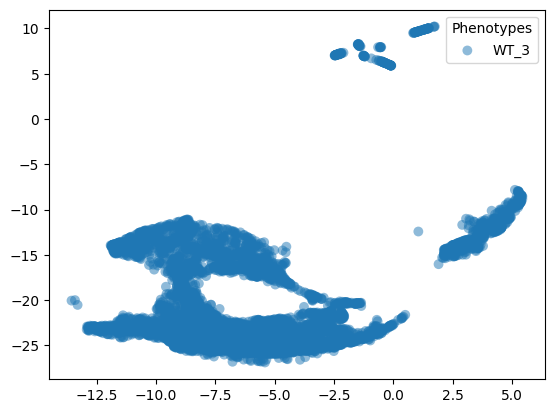

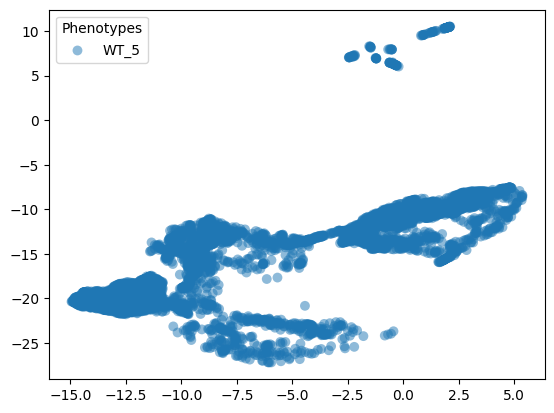

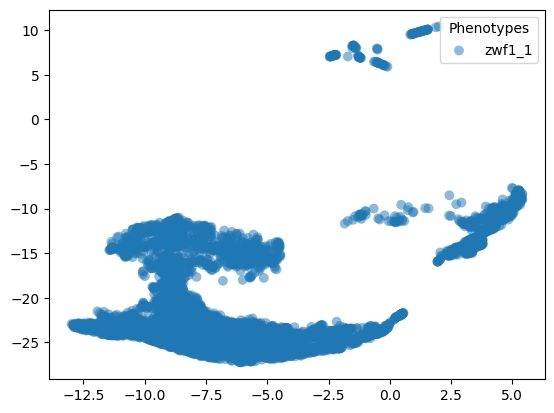

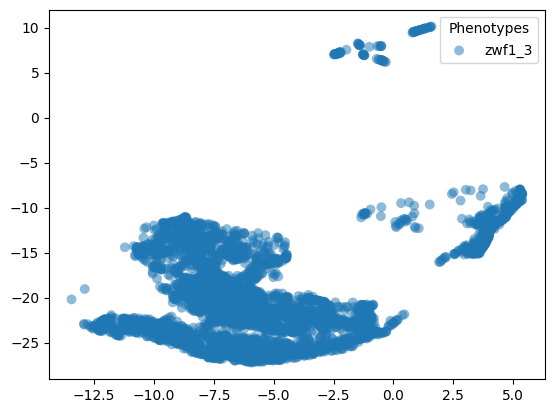

200


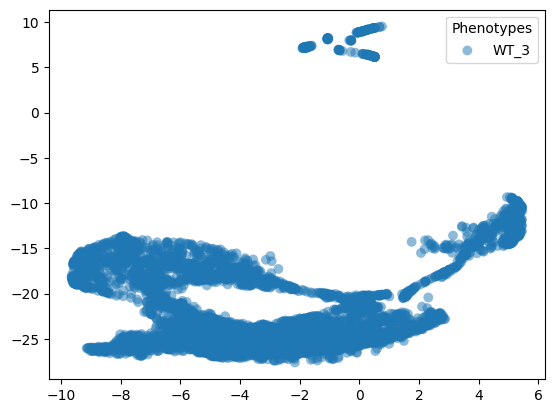

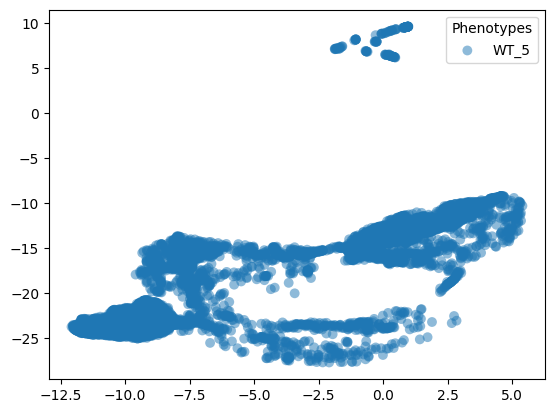

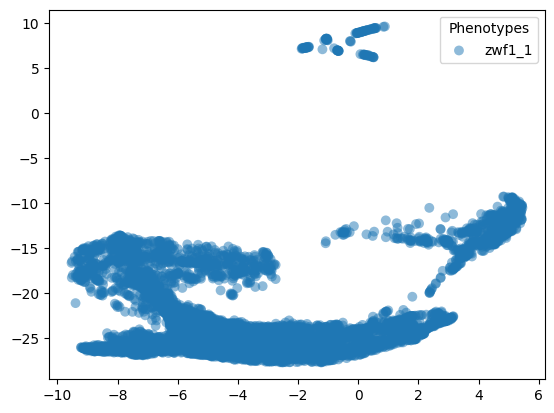

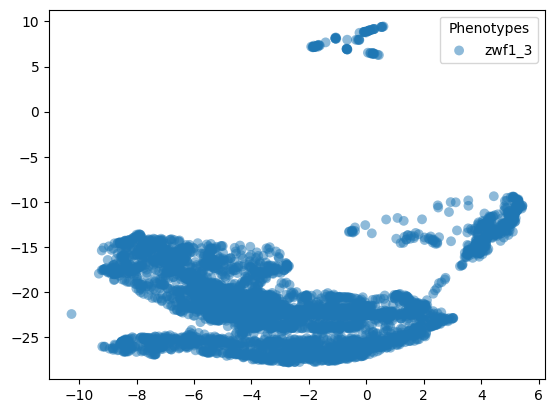

300


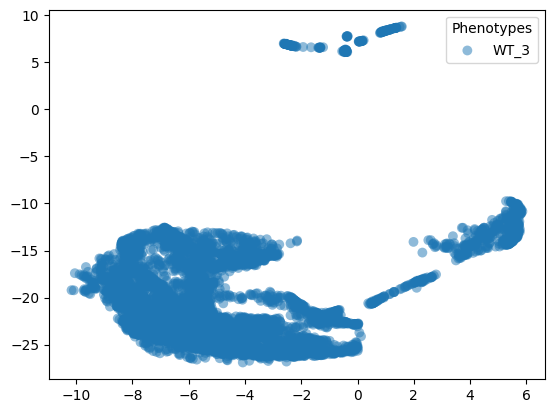

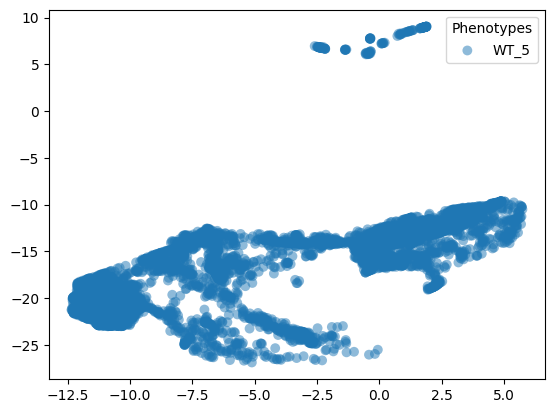

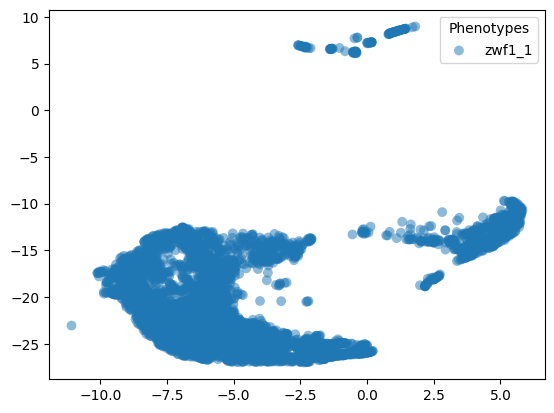

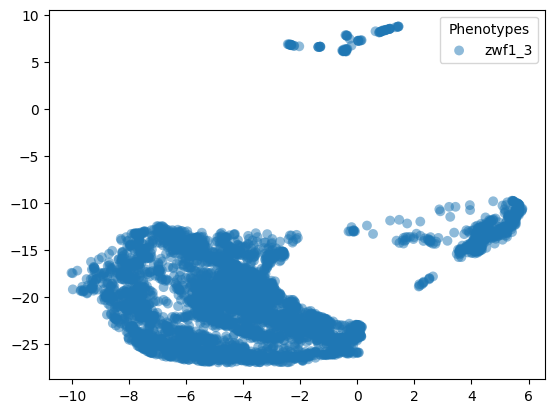

In [27]:
for p in range(100, 301, 100):
	print(p)
	# S_emb_concat_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
	# S_emb_concat_red = TSNE(n_components=2, perplexity=p, n_jobs=-1).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
	S_emb_concat_red = umap.UMAP(n_components=2, n_neighbors=p, min_dist=0.2, metric="cosine", random_state=42).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
	# S_emb_concat_red = umap.UMAP().fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)

	# S_emb_concat_red = PCA(n_components=2, random_state=42).fit_transform(S_emb_concat)

	df_S_emb_concat_red = pd.DataFrame(S_emb_concat_red)
	df_S_emb_concat_red["Subgroup"] = df_S_emb_concat.iloc[:, -1].values
	df_S_emb_concat_red


	for k in unique_labels:
		df_temp = df_S_emb_concat_red[df_S_emb_concat_red["Subgroup"] == k]
		plt.scatter(df_temp.iloc[:, 0], df_temp.iloc[:, 1], label=train_set[k], s=50, alpha=0.5, edgecolors='none')
		plt.legend(title="Phenotypes")
		plt.show()

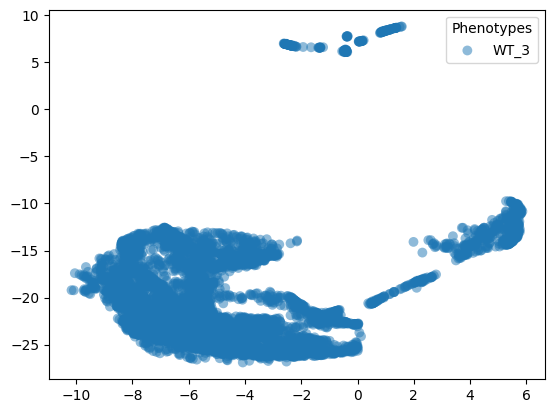

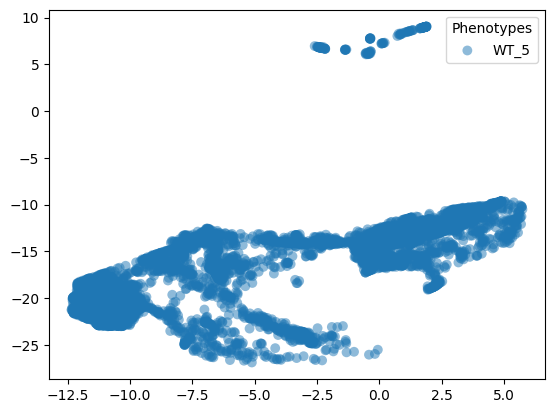

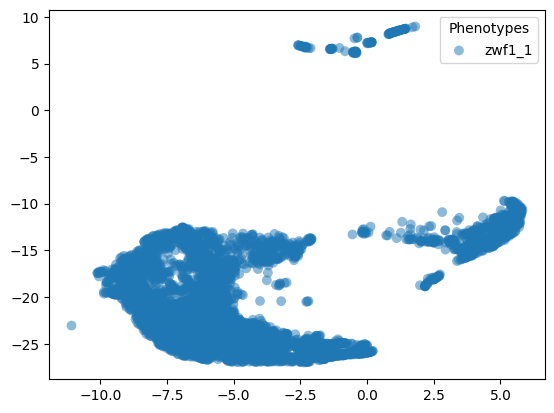

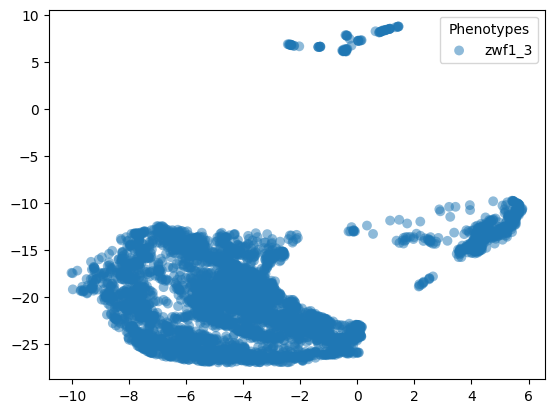

In [28]:
# S_emb_concat_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
# S_emb_concat_red = TSNE(n_components=2, perplexity=p, n_jobs=-1).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
S_emb_concat_red = umap.UMAP(n_components=2, n_neighbors=300, min_dist=0.2, metric="cosine", random_state=42).fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)
# S_emb_concat_red = umap.UMAP().fit_transform(df_S_emb_concat.iloc[:, 1:-1].values)

# S_emb_concat_red = PCA(n_components=2, random_state=42).fit_transform(S_emb_concat)

df_S_emb_concat_red = pd.DataFrame(S_emb_concat_red)
df_S_emb_concat_red["Subgroup"] = df_S_emb_concat.iloc[:, -1].values
df_S_emb_concat_red

for k in unique_labels:
	df_temp = df_S_emb_concat_red[df_S_emb_concat_red["Subgroup"] == k]
	plt.scatter(df_temp.iloc[:, 0], df_temp.iloc[:, 1], label=train_set[k], s=50, alpha=0.5, edgecolors='none')
	plt.legend(title="Phenotypes")
	plt.show()

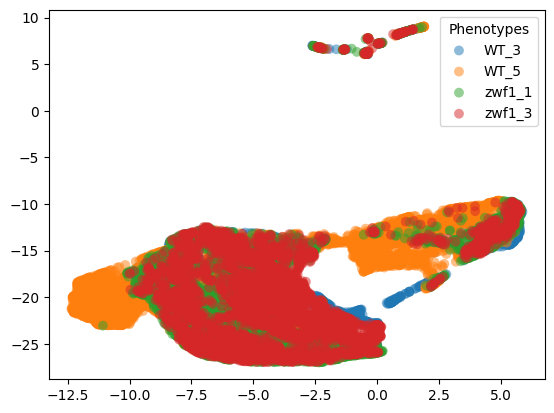

In [29]:
for k in unique_labels:
	df_temp = df_S_emb_concat_red[df_S_emb_concat_red["Subgroup"] == k]     
	plt.scatter(df_temp.iloc[:, 0], df_temp.iloc[:, 1], label=train_set[k], s=50, alpha=0.5, edgecolors='none')
plt.legend(title="Phenotypes")
plt.show()

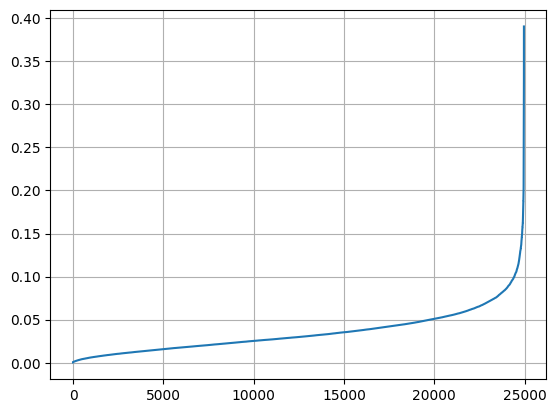

In [30]:
# calculate eps
from sklearn.neighbors import NearestNeighbors

neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(S_emb_concat_red)
distances, indices = nbrs.kneighbors(S_emb_concat_red)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
plt.grid()
plt.show()

[-1  0  1]


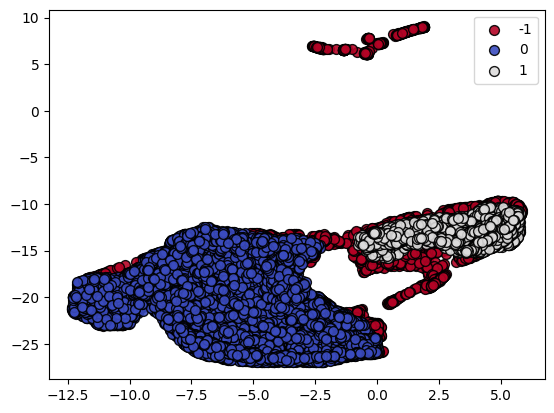

In [41]:
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN

# clustering = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(S_emb_concat_red)
# clustering = DBSCAN(eps=0.05, min_samples=20).fit(S_emb_concat_red) # 1.0, 1.0, 0.7
clustering = HDBSCAN(min_cluster_size=500).fit(S_emb_concat_red) # 1.0, 1.0, 0.7
labels = clustering.labels_
print(np.unique(labels))

colors = plt.get_cmap("coolwarm")(np.linspace(0, 1, len(np.unique(labels))))
# colors[-1] = [0.7, 0.7, 0.7, 1]

for i, label in enumerate(np.unique(labels)):
	index = np.where(labels == label)[0]
	plt.scatter(S_emb_concat_red[index, 0], S_emb_concat_red[index, 1], c=colors[label], label=label, s=50, alpha=0.9, edgecolors='k')

# plt.scatter(S_emb_concat_red[:, 0], S_emb_concat_red[:, 1], c=labels, s=10, alpha=0.2, edgecolors='none')
plt.legend()
plt.show()

In [46]:
for k in range(10, 201, 10):
	# clustering = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(S_emb_concat_red)
	clustering = DBSCAN(eps=0.07, min_samples=k).fit(S_emb_concat_red) # 1.0, 1.0, 0.7
	labels = clustering.labels_
	# print(np.unique(labels))

	colors = plt.get_cmap("coolwarm")(np.linspace(0, 1, len(np.unique(labels))))
	colors[-1] = [0.7, 0.7, 0.7, 1]

	for i, label in enumerate(np.unique(labels)):
			index = np.where(labels == label)[0]
			plt.scatter(S_emb_concat_red[index, 0], S_emb_concat_red[index, 1], c=colors[label], label=label, s=50, alpha=0.9, edgecolors='k')

	# plt.scatter(S_emb_concat_red[:, 0], S_emb_concat_red[:, 1], c=labels, s=10, alpha=0.2, edgecolors='none')
	plt.legend()
	plt.show()

In [ ]:
dict_clusters = {}
for i, label in enumerate(np.unique(labels)):
	index = np.where(labels == label)[0]
	# print(index[0])
	df_temp = df_S_emb_concat.iloc[index, [0, 1]]
	
	df_temp_filter = df_temp.value_counts("id").to_frame()
	df_temp_filter = df_temp_filter[df_temp_filter["count"]  == len(train_set)]
	dict_clusters[label] = len(list(df_temp_filter.index))

print(train_set)
dict_clusters

In [ ]:
# count

total = len(df_S_emb_concat) // len(train_set)
count = 0
for key in dict_clusters:
	count += dict_clusters[key]

print("{}/{}, {}%".format(count, total, (count * 100) / total))

---

In [ ]:
# S_emb_concat_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=50).fit_transform(S_emb_concat)
S_emb_concat_red = umap.UMAP(n_components=2, n_neighbors=100, min_dist=0.1, metric="cosine", random_state=42).fit_transform(S_emb_concat)
# S_emb_concat_red = PCA(n_components=2, random_state=42).fit_transform(S_emb_concat)

# db = HDBSCAN(metric="cosine")
# hdb.fit(S_emb_concat)
	
for min_ in [2, 3, 4, 5, 10, 50, 100]:
	hdb = HDBSCAN(min_cluster_size=min_, metric="cosine")
	hdb.fit(S_emb_concat)
	labels = hdb.labels_
	# labels = hdb.dbscan_clustering(cut_distance=min_)
	
	# print(np.unique(labels))

	""" for i, label in enumerate(np.unique(labels)):
		index = np.where(labels == label)
		plt.scatter(S_emb_concat_red[index, 0], S_emb_concat_red[index, 1], c=colors[i], label=label, s=50, alpha=0.2, edgecolors='none') """

	plt.scatter(S_emb_concat_red[:, 0], S_emb_concat_red[:, 1], c=y, s=10, alpha=0.2, edgecolors='none')
	plt.legend()
	plt.show()

In [ ]:
for p in list(range(5, 101, 5)):
	S_emb_concat_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=p).fit_transform(S_emb_concat)
	# S_emb_concat_red = umap.UMAP(n_components=2, random_state=42).fit_transform(S_emb_concat)
	# S_emb_concat_red = PCA(n_components=2, random_state=42).fit_transform(S_emb_concat)

	for i, label in enumerate(np.unique(labels)):
		index = np.where(labels == label)
		plt.scatter(S_emb_concat_red[index, 0], S_emb_concat_red[index, 1], c=colors[i], label=i, s=20, edgecolors="k")
	plt.legend()
	plt.show()

#### Plot 

TSNE

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

S1_emb_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=100).fit_transform(S1_emb)
S2_emb_red = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=100).fit_transform(S2_emb)

plt.scatter(S1_emb_red[:, 0], S1_emb_red[:, 1])
plt.scatter(S2_emb_red[:, 0], S2_emb_red[:, 1])

plt.show()

UMAP

In [ ]:
import umap

S1_emb_red = umap.UMAP(n_components=2, random_state=42).fit_transform(S1_emb)
S2_emb_red = umap.UMAP(n_components=2, random_state=42).fit_transform(S2_emb)

# plt.scatter(S1_emb_red[:, 0], S1_emb_red[:, 1], edgecolors="k", label=train_set[0])
plt.scatter(S2_emb_red[:, 0], S2_emb_red[:, 1], edgecolors="k", label=train_set[1])
plt.legend()
plt.show()

In [ ]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6]])

# Concatenate along the first axis (rows)
np.concatenate((a, b), axis=0)

PCA

In [ ]:
from sklearn.decomposition import PCA

S1_emb_red = PCA(n_components=2, random_state=42).fit_transform(S1_emb)
S2_emb_red = PCA(n_components=2, random_state=42).fit_transform(S2_emb)

plt.scatter(S1_emb_red[:, 0], S1_emb_red[:, 1])
plt.scatter(S2_emb_red[:, 0], S2_emb_red[:, 1])

plt.show()

#### Truth

In [ ]:
""" print(data)
print(test_pairs.shape)
print(test_pairs) """

In [ ]:
""" if (data == "ACM_DBLP"):
	test_pairs_ = test_pairs
elif (data == "Douban Online_Offline"):
	test_pairs_ = test_pairs.T
	
truth = test_pairs_[test_pairs_[:, 1].argsort()]
print(truth.shape)
truth """

In [ ]:
""" truth_ = test_pairs_[test_pairs_[:, 0].argsort()]
print(truth_.shape)
truth_ """

#### Option 0

In [ ]:
def hungarian(D):
	print("0")
	P = torch.zeros_like(D)
	matrix = D.tolist()
	m = Munkres()
	print("1")
	indexes = m.compute(matrix)
	print("2")
	total = 0
	for r, c in tqdm(indexes):
		print(r)
		P[r][c] = 1
		total += matrix[r][c]
	return P.t()

""" X = hungarian(D)
print(X.shape)
# online_offline: 215m
# acm_dblp: 2112m
X """

In [ ]:
# save

""" X = X.cpu().numpy()
np.save("P_hungarian_ACM_DBLP", X) """

In [ ]:
# load

""" X = np.load("P_hungarian.npy")
X """

In [ ]:
""" option0 = []
m, n = X.shape
for i in range(m):
	for j in range(n):
		if X[i][j] == 1:
			option0.append([j, i]) # S, S_hat
option0 = np.array(option0)
print(len(option0))
option0 """

In [ ]:
""" matching = test_matching(truth, option0)
print(len(matching))
print(len(matching) / len(truth))
matching """

#### Option 1

In [ ]:
total_cost, assignments = hungarian_algorithm(D.cpu())

In [ ]:
option1 = np.array(assignments)
option1 = option1[option1[:, 1].argsort()]
print(option1.shape)
option1

In [ ]:
option1_ = option1[:, [1, 0]]
option1_

In [ ]:
""" matching = test_match(truth, option1)
print(len(matching))
print(len(matching) / len(truth))
matching """

In [ ]:
# Analysis

def match_nodes(option, map1, map2):
	df_match = pd.DataFrame(option)
	df_match.columns = ["g1", "g2"]
	df_match

	df_match.replace({"g1": map1}, inplace=True) 
	df_match.replace({"g2": map2}, inplace=True) 
	df_match

	df_match = df_match[df_match["g1"] == df_match["g2"]]
	return sorted(df_match.iloc[:, 0].values)

df_match = match_nodes(option1.copy(), map1, map2)
df_match

In [ ]:
""" G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)

plot_match(G1, G2, matching)"""

#### Option 2

In [ ]:
import pygmtools as pygm

X = pygm.hungarian(D.cpu().numpy())
print(X.shape)
X

In [ ]:
option2 = matrix_to_edge(X)
option2

In [ ]:
option2_ = option2[:, [1, 0]]
option2_

In [ ]:
""" matching = test_match(truth, option2)
print(len(matching))
print(len(matching) / len(truth))
matching """

In [ ]:
df_match = match_nodes(option2.copy(), map1, map2)
df_match

In [ ]:
""" G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching) """

#### Option 3

In [ ]:
indices = []
for i in range(D.shape[0]):
	dist_list = D[i]
	sorted_neighbors = torch.argsort(dist_list).cpu()
	indices.append([i, sorted_neighbors[0]])

option3 = np.array(indices)
option3 = option3[option3[:, 1].argsort()]
print(option3.shape)
option3

In [ ]:
option3_ = option3[:, [1, 0]]
option3_

In [ ]:
""" matching = test_match(truth, option3)
print(len(matching))
print(len(matching) / len(truth))
matching """

In [ ]:
df_match = match_nodes(option3, map1, map2)
df_match

In [ ]:
""" G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching) """

#### Option 4

In [ ]:
X = greedy_match(D)
X = X.todense()
X = np.array(X)
print(X.shape)
print(X)

In [ ]:
option4 = matrix_to_edge(X)
option4

In [ ]:
option4_ = option4[:, [1, 0]]
option4_

In [ ]:
""" matching = test_match(truth, option4)
print(len(matching))
print(len(matching) / len(truth))
matching """

In [ ]:
df_match = match_nodes(option4, map1, map2)
df_match

In [ ]:
""" G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching) """

#### Option 5

In [ ]:
D_ = complete_to_square(D.cpu(), pad_value=100.0)
print(D_.shape)
D_

In [ ]:
X = get_match(torch.tensor(D_), device)
print(X.shape)
X

In [ ]:
option5 = matrix_to_edge(X)
option5

In [ ]:
option5_ = option5[:, [1, 0]]
option5_

In [ ]:
""" matching = test_match(truth, option5_) # ACM_DBLP (option5_)
print(len(matching))
print(len(matching) / len(truth))
matching """

In [ ]:
df_match = match_nodes(option5, map1, map2)
df_match

In [ ]:
""" G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching) """

---

In [ ]:
a = torch.tensor([[0.0,  0.0], [0.0, 1.0], [0.0,  2.0]])
print(a)
b = torch.tensor([[0.0, 1.0 ], [1.0,  1.0]])
print(b)
torch.cdist(a, b, p=2)

In [ ]:
a = torch.tensor([[4.01, 3.0, 2.0, 0.1, 4.0]])
print(a)
torch.argsort(a, dim=1)

In [ ]:
a = np.array([[9, 2, 3],
			  [4, 5, 6],
			  [7, 0, 5]])

a[a[:, 2].argsort()]

In [ ]:
a = torch.randn(4, 4)
print(a)

torch.argmin(a)
